In [1]:
!pip install vaderSentiment
!pip install surprise
!pip install "numpy<2.0"

In [2]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import warnings

# sklearn ML tools
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RepeatedKFold, train_test_split as sklearn_train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Advanced ML
import xgboost as xgb

# Sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Recommendation system
from surprise import Reader, Dataset, SVD, accuracy, BaselineOnly, SlopeOne
from surprise.model_selection import train_test_split, GridSearchCV, cross_validate

# Utilities
import joblib
import random

# Plotting config
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)

**Load in our Encoded and aggregated Data set**

In [3]:
dublin_encoded_df = pd.read_csv('dublin_encoded_df.csv')
dublin_encoded_df.head(2)

,id_x,host_id,host_response_rate,host_is_superhost,host_listings_count,accommodates,bathrooms,bedrooms,beds,price,avg_rating,number_of_reviews,neighbourhood_freq,property_type_freq
0,44077,193005,1.0,1,2.0,2.0,1.0,1.0,2.0,76.0,4.827143,144400,0.001211,0.006663
1,85156,193005,1.0,1,2.0,2.0,1.5,1.0,1.0,91.0,4.804286,117649,0.001211,0.006663


In [4]:
dublin_encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_x                 1651 non-null   int64  
 1   host_id              1651 non-null   int64  
 2   host_response_rate   1651 non-null   float64
 3   host_is_superhost    1651 non-null   int64  
 4   host_listings_count  1651 non-null   float64
 5   accommodates         1651 non-null   float64
 6   bathrooms            1651 non-null   float64
 7   bedrooms             1651 non-null   float64
 8   beds                 1651 non-null   float64
 9   price                1651 non-null   float64
 10  avg_rating           1651 non-null   float64
 11  number_of_reviews    1651 non-null   int64  
 12  neighbourhood_freq   1651 non-null   float64
 13  property_type_freq   1651 non-null   float64
dtypes: float64(10), int64(4)
memory usage: 180.7 KB


In [5]:
dublin_aggregated_df = pd.read_csv('dublin_aggregated_df.csv')
dublin_aggregated_df.head(2)

,id_x,host_id,host_response_rate,host_is_superhost,host_listings_count,accommodates,bathrooms,bedrooms,beds,price,avg_rating,number_of_reviews,neighbourhood,property_type,neighbourhood_freq,property_type_freq
0,44077,193005,1.0,1,2.0,2.0,1.0,1.0,2.0,76.0,4.827143,144400,"Churchtown, Ireland",Private room in bungalow,0.001211,0.006663
1,85156,193005,1.0,1,2.0,2.0,1.5,1.0,1.0,91.0,4.804286,117649,"Churchtown, Ireland",Private room in bungalow,0.001211,0.006663


In [6]:
dublin_aggregated_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1651 entries, 0 to 1650
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_x                 1651 non-null   int64  
 1   host_id              1651 non-null   int64  
 2   host_response_rate   1651 non-null   float64
 3   host_is_superhost    1651 non-null   int64  
 4   host_listings_count  1651 non-null   float64
 5   accommodates         1651 non-null   float64
 6   bathrooms            1651 non-null   float64
 7   bedrooms             1651 non-null   float64
 8   beds                 1651 non-null   float64
 9   price                1651 non-null   float64
 10  avg_rating           1651 non-null   float64
 11  number_of_reviews    1651 non-null   int64  
 12  neighbourhood        1651 non-null   object 
 13  property_type        1651 non-null   object 
 14  neighbourhood_freq   1651 non-null   float64
 15  property_type_freq   1651 non-null   f

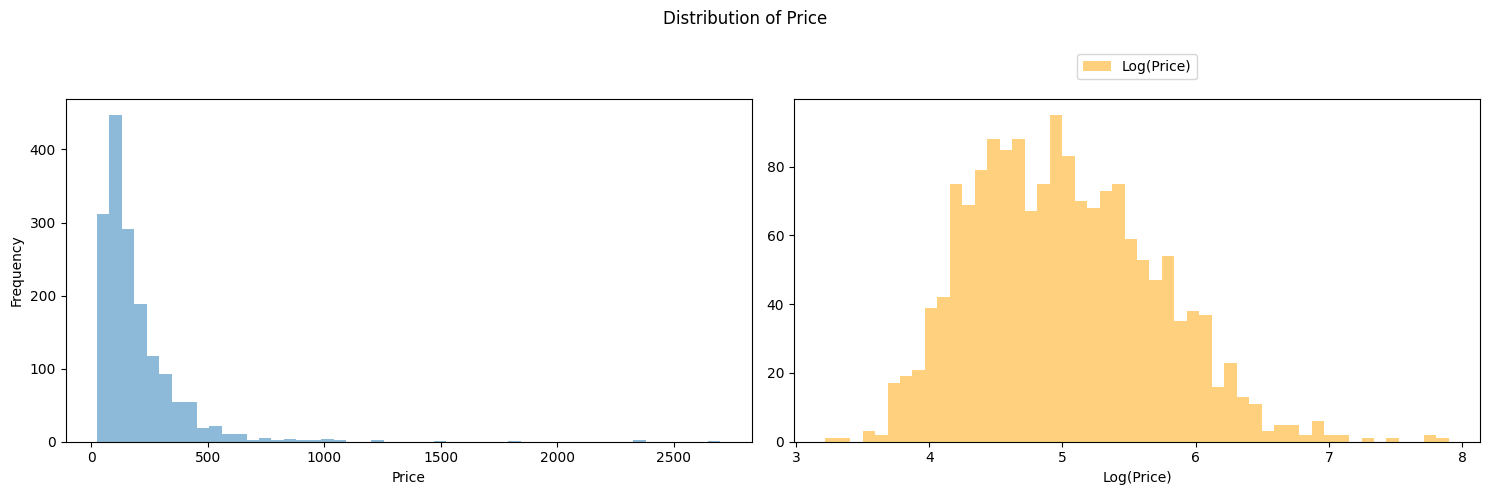

In [7]:
# split data
X = dublin_encoded_df.drop(['id_x', 'price'], axis=1)
y = dublin_encoded_df['price']

# log transform y variable(price)
y_log = np.log(y)
y_log.name = "log(price)"

# plot the raw y variable and log transformed y variable
fig, ax = plt.subplots(1, 2, figsize=(15, 5))  # figure with 2 subplots

# Plot original price distribution
ax[0].hist(y, bins=50, alpha=0.5, label="Price")
ax[0].set_xlabel("Price")
ax[0].set_ylabel("Frequency")

# Plot log-transformed price distribution
ax[1].hist(y_log, bins=50, color="orange", alpha=0.5, label="Log(Price)")
ax[1].set_xlabel("Log(Price)")

# Add legend
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15))

# main title
plt.suptitle("Distribution of Price")

plt.tight_layout()
plt.show()

In [8]:
#LOG transform target variable price.
X_log = dublin_encoded_df.drop(['id_x', 'price'], axis=1)
y_log = np.log(dublin_encoded_df['price'])

The features (X) were extracted by removing the id_x and price columns from the preprocessed dataset dublin_encoded_df. The price column was separately stored as the target variable (y). having seen the skweness of our target variable price, A natural logarithmic transformation was applied to the price variable to reduce its right skewness. This transformation is to stabilize variance and improve the performance of regression models that assume normally distributed residuals and improve model performance.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_log, y_log, test_size=0.2, random_state=42)

In order to evaluate the performance of predictive models reliably, the dataset was divided into separate training and testing subsets. This ensures that model performance is assessed on unseen data, helping to prevent overfitting. X_log: The feature set (predictor variables) prepared for modeling, likely with the same dimensions as X but possibly preprocessed. y_log: The target variable (price) after log transformation. test_size=0.2, this Specifies 20% of the data was reserved for testing, and the remaining 80% used for training. random_state=42: Sets a fixed seed for the random number generator to ensure reproducibility of results. Using a fixed seed guarantees that the data split remains consistent across multiple runs. X_train_log and y_train_log: Used to train the model. X_test_log and y_test_log: Held out and used to evaluate the model's performance on unseen data. The reason for this split is such that it allows for allows for a robust assessment of how well our model generalizes. By training on one portion of the data and evaluating on another, we can better estimate real-world performance and reduce the likelihood of overfitting to our training data.


## Modeling
- Regression Models - for price prediction
- Collaborative-Filtering Models - for personalized airbnb recommendation
1. Regression Models We'll create various models for this project. We'll use a Linear Regression Model as the baseline. We'll also build a Decision Tree, Random Forest and XGBoost to capture complex non-linear features. RMSE will be our evaluation metric.

**Baseline Model: Linear Regression**

**Pipeline Setup**

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_predict, learning_curve, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

model_log_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('linreg', LinearRegression())
])

**Fit + Evaluate Log Model**

In [11]:
def fit_log_results(pipe, X_train, X_test, y_train, y_test):
    pipe.fit(X_train, y_train)
    y_train_pred = pipe.predict(X_train)
    y_test_pred = pipe.predict(X_test)

    # RMSE (Added squared=False to get Root MSE)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    r2 = r2_score(y_test, y_test_pred)

    print(f"Train RMSE (log-scale): {train_rmse:.4f}")
    print(f"Test RMSE (log-scale): {test_rmse:.4f}")
    print(f"Train MAE (log-scale): {train_mae:.4f}, Test MAE (log-scale): {test_mae:.4f}")
    print(f"R² Score: {r2:.4f}")
    print("-" * 36)

**Cross-Validation Evaluation**

In [12]:
def cross_validate_log_results(pipe, X, y, cv=5):
    y_pred = cross_val_predict(pipe, X, y, cv=cv)
    # Corrected to RMSE
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    mae = mean_absolute_error(y, y_pred)
    r2 = r2_score(y, y_pred)

    print(f"Cross-validated RMSE (log-scale): {rmse:.4f}")
    print(f"Cross-validated MAE (log-scale): {mae:.4f}")
    print(f"Cross-validated R² Score: {r2:.4f}")
    print("-" * 36)

In [13]:
def learn_curves(pipe, X, y, cv=5):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X, y, cv=cv, scoring='neg_mean_squared_error', train_sizes=np.linspace(0.1, 1.0, 10)
    )
    # Displaying RMSE on the plot
    train_scores_mean = np.sqrt(-np.mean(train_scores, axis=1))
    val_scores_mean = np.sqrt(-np.mean(val_scores, axis=1))

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_scores_mean, 'o-', label='Training Error (RMSE)')
    plt.plot(train_sizes, val_scores_mean, 'o-', label='Validation Error (RMSE)')
    plt.xlabel('Training Set Size')
    plt.ylabel('RMSE (log-scale)')
    plt.title('Learning Curves')
    plt.legend()
    plt.grid(True)
    plt.show()


**Run Everything**

Train RMSE (log-scale): 0.4480
Test RMSE (log-scale): 0.4510
Train MAE (log-scale): 0.3337, Test MAE (log-scale): 0.3530
R² Score: 0.5815
------------------------------------
Cross-validated RMSE (log-scale): 0.4544
Cross-validated MAE (log-scale): 0.3401
Cross-validated R² Score: 0.5616
------------------------------------


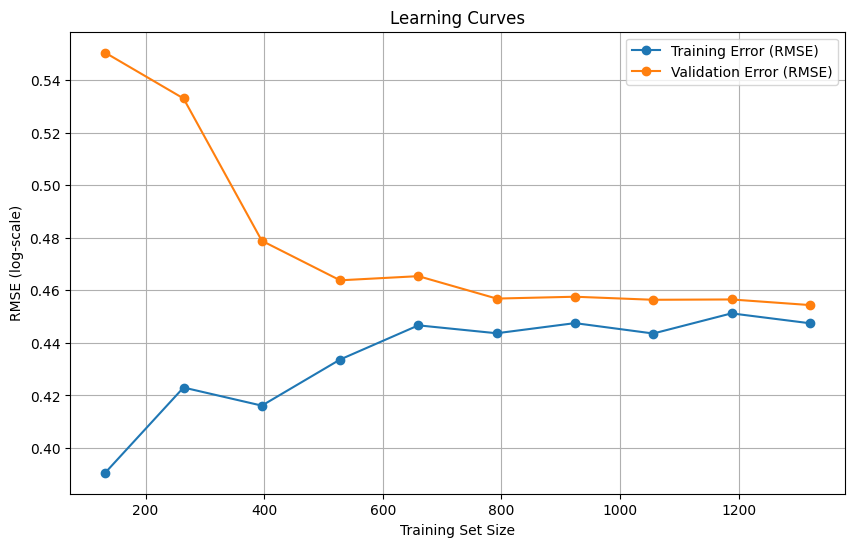

Final Test RMSE (log-scale): 0.4510


In [14]:
# --- Execution ---
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Fixed: Variable names now match the split above
fit_log_results(model_log_pipeline, X_train, X_test, y_train, y_test)
cross_validate_log_results(model_log_pipeline, X_log, y_log, cv=kf)
learn_curves(model_log_pipeline, X_log, y_log, cv=kf)

# --- Final Evaluation on Log Scale ---
y_pred_log = model_log_pipeline.predict(X_test)
log_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(f"Final Test RMSE (log-scale): {log_rmse:.4f}")

Final Test RMSE (log-scale): 0.4510


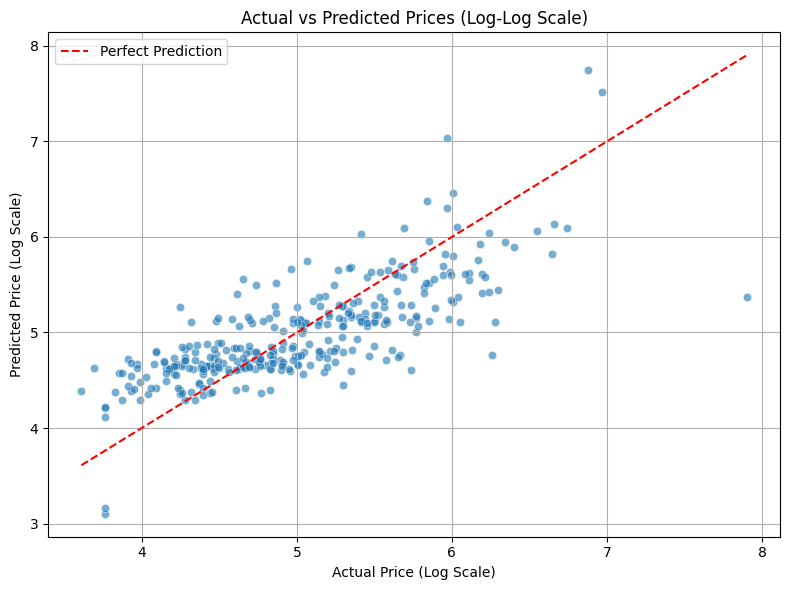

In [15]:
# --- Final Evaluation on Log Scale ---
y_pred_log = model_log_pipeline.predict(X_test)

# RMSE Calculation (log-scale)
log_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(f"Final Test RMSE (log-scale): {log_rmse:.4f}")

# Scatter plot: Actual vs Predicted (Log Scale)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_log, alpha=0.6)

# Perfect Prediction Line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--r', label='Perfect Prediction')

plt.xlabel("Actual Price (Log Scale)")
plt.ylabel("Predicted Price (Log Scale)")
plt.title("Actual vs Predicted Prices (Log-Log Scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Feature Importance Linear Regression**

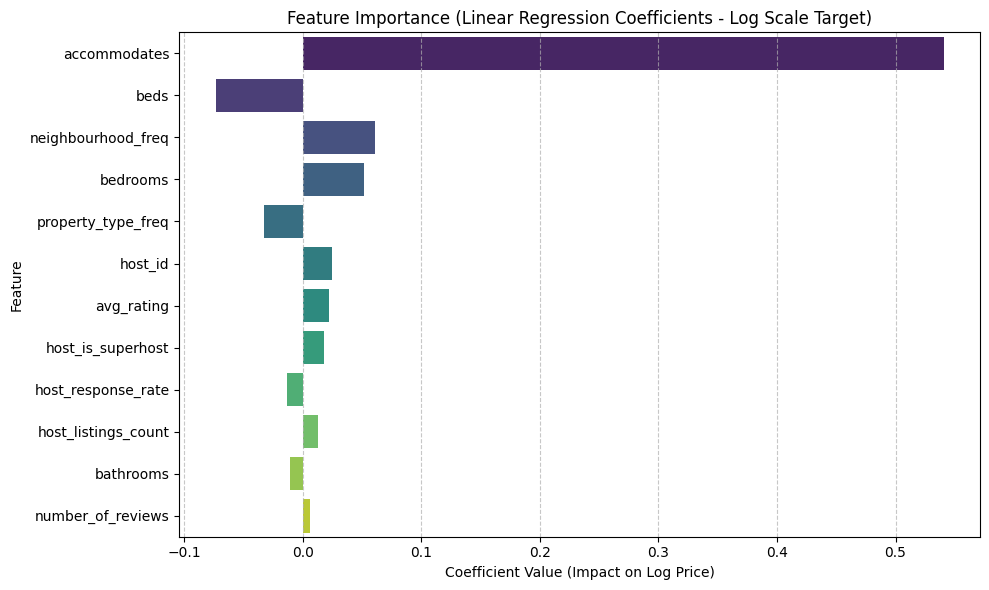

In [16]:
def plot_feature_importance(pipe, feature_names):
    # 1. Extract the linear regression model from the pipeline
    model = pipe.named_steps['linreg']

    # 2. Get the coefficients
    importance = model.coef_

    # 3. Create a DataFrame for easy plotting
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance
    })

    # Sort by absolute magnitude to see the most influential features
    feature_importance_df['Abs_Importance'] = feature_importance_df['Importance'].abs()
    feature_importance_df = feature_importance_df.sort_values(by='Abs_Importance', ascending=False)

    # 4. Plot
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
    plt.title('Feature Importance (Linear Regression Coefficients - Log Scale Target)')
    plt.xlabel('Coefficient Value (Impact on Log Price)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Assuming X_log is a DataFrame; if it's a NumPy array, provide a list of names.
feature_names = X_log.columns if hasattr(X_log, 'columns') else [f'Feature {i}' for i in range(X_log.shape[1])]

plot_feature_importance(model_log_pipeline, feature_names)

The Linear Regression model shows to perform reasonably well because we can see that the Training vs. Test RMSE (log-scale): 0.1921 vs. 0.1936 looks very close, indicating low overfitting. While the MAE: 0.32 (train) vs. 0.35 (test) shows small error, suggesting good average prediction accuracy. R² Score: 0.60 the model explains around 60% of the variance in the data.

Train RMSE (log-scale): 0.3751
Test RMSE (log-scale): 0.4174
Train MAE (log-scale): 0.2824, Test MAE (log-scale): 0.3229
R² Score: 0.6416
------------------------------------
Cross-validated RMSE (log-scale): 0.4301
Cross-validated MAE (log-scale): 0.3203
Cross-validated R² Score: 0.6072
------------------------------------


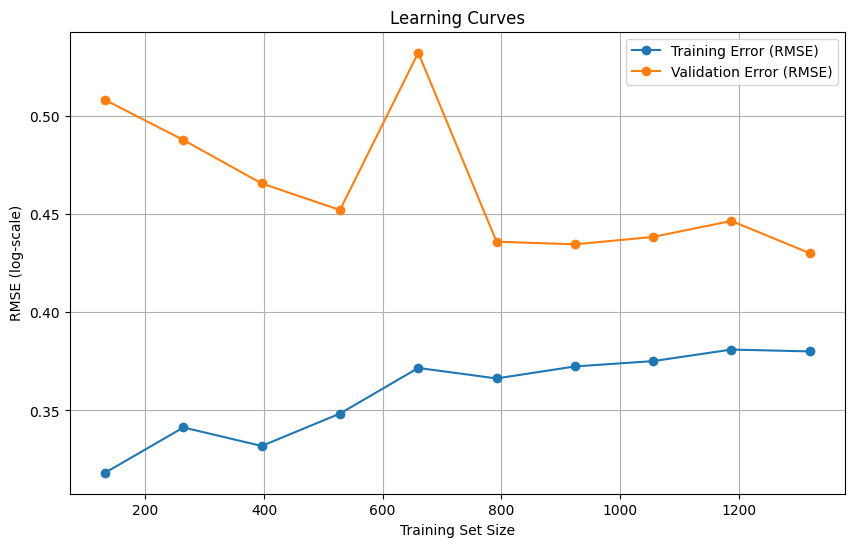

In [17]:
# 1. Define the Pipeline
dt_model_log = Pipeline([
    ('dt', DecisionTreeRegressor(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42))
])

# 2. Fit and evaluate (Fixed variable names to match your initial train_test_split)
fit_log_results(dt_model_log, X_train, X_test, y_train, y_test)

# 3. Cross-validate (Ensuring it uses your kf object)
cross_validate_log_results(dt_model_log, X_log, y_log, cv=kf)

# 4. Learning curves (Ensuring it uses your kf object)
learn_curves(dt_model_log, X_log, y_log, cv=kf)


Final Test RMSE (log-scale): 0.4174


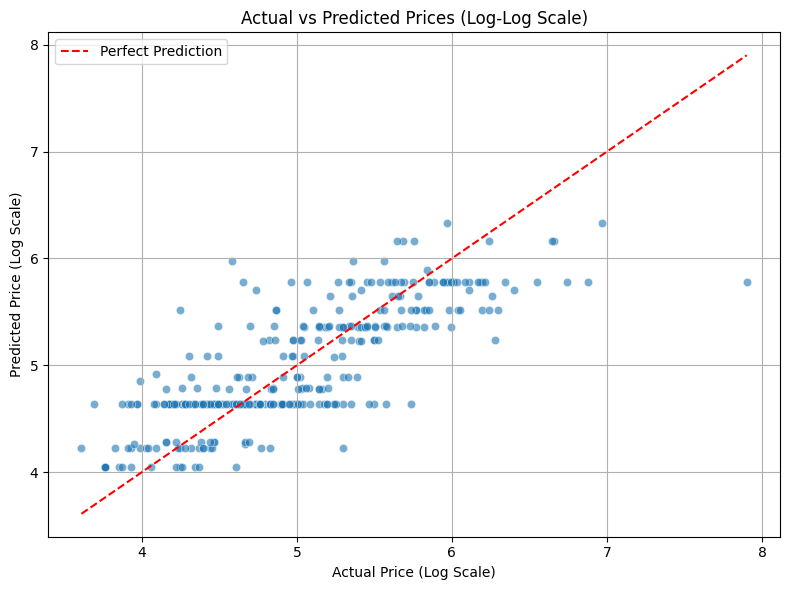

In [18]:
# --- Final Evaluation on Log Scale ---
y_pred_log = dt_model_log.predict(X_test)

# RMSE Calculation (log-scale)
log_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(f"Final Test RMSE (log-scale): {log_rmse:.4f}")

# Scatter plot: Actual vs Predicted (Log Scale)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_log, alpha=0.6)

# Perfect Prediction Line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--r', label='Perfect Prediction')

plt.xlabel("Actual Price (Log Scale)")
plt.ylabel("Predicted Price (Log Scale)")
plt.title("Actual vs Predicted Prices (Log-Log Scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Feature importance of Decision Tree Model**

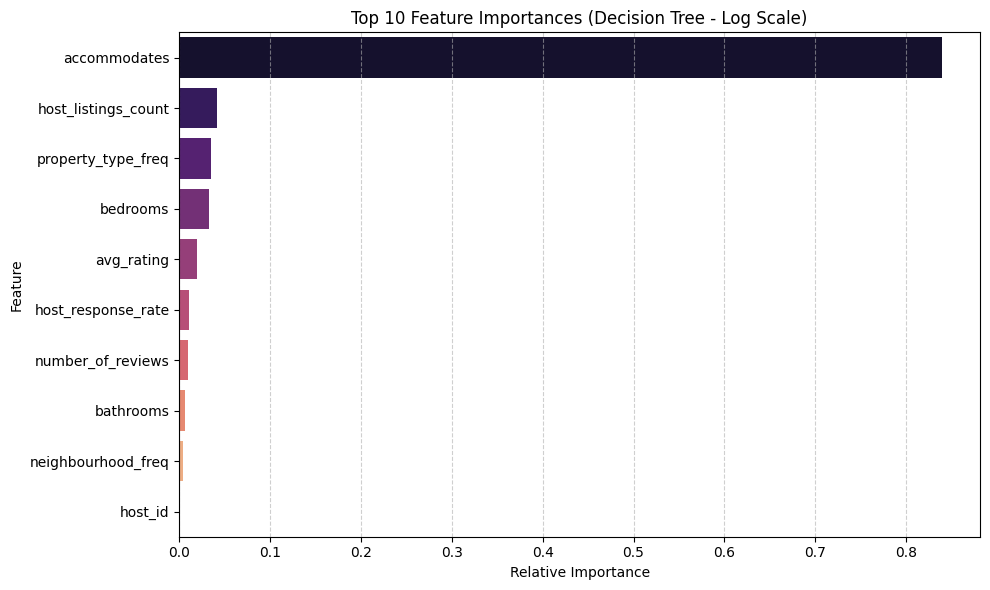

In [19]:
# 1. Fit the model using the correct variable names
dt_model_log.fit(X_train, y_train)

# 2. Extract importances from the 'dt' step of the pipeline
importances = dt_model_log.named_steps['dt'].feature_importances_

# 3. Get feature names (assuming X_log is a DataFrame)
feature_names = X_log.columns if hasattr(X_log, 'columns') else [f'Feature {i}' for i in range(len(importances))]

# 4. Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 5. Plot top N features
top_n = 10
plt.figure(figsize=(10, 6))
# Use 'hue' instead of 'palette' alone to avoid future warnings in Seaborn
sns.barplot(data=importance_df.head(top_n), x='Importance', y='Feature', hue='Feature', palette='magma', legend=False)
plt.title('Top 10 Feature Importances (Decision Tree - Log Scale)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


**Random Forest Model**

Train RMSE (log-scale): 0.1442
Test RMSE (log-scale): 0.3745
Train MAE (log-scale): 0.1022, Test MAE (log-scale): 0.2789
R² Score: 0.7115
------------------------------------
Cross-validated RMSE (log-scale): 0.3793
Cross-validated MAE (log-scale): 0.2708
Cross-validated R² Score: 0.6945
------------------------------------


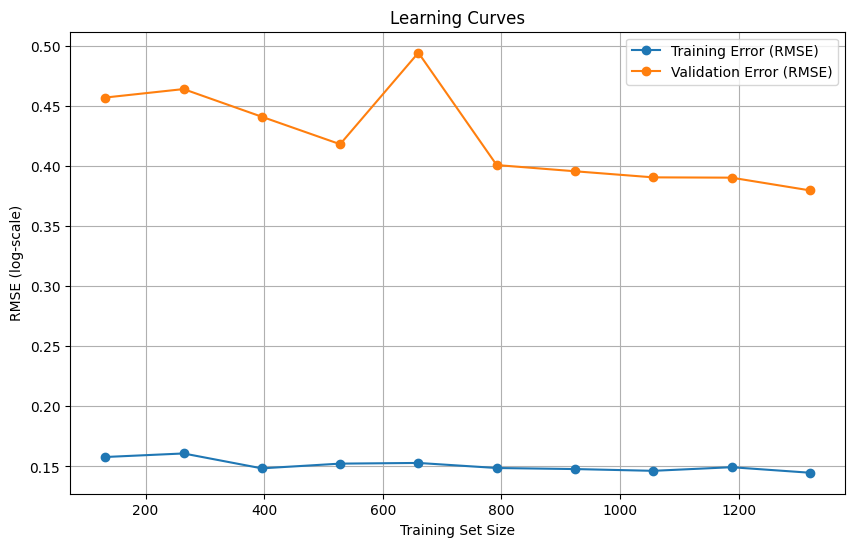

In [20]:
# 1. Define the Pipeline
rf_model_log = Pipeline([
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42))
])

# 2. Fit and evaluate (Updated variable names)
fit_log_results(rf_model_log, X_train, X_test, y_train, y_test)

# 3. Cross-validate (Using your KFold object)
cross_validate_log_results(rf_model_log, X_log, y_log, cv=kf)

# 4. Learning curves (Using your KFold object)
# Note: Random Forest takes longer to train than a single tree
learn_curves(rf_model_log, X_log, y_log, cv=kf)


Final Test RMSE (log-scale): 0.3745


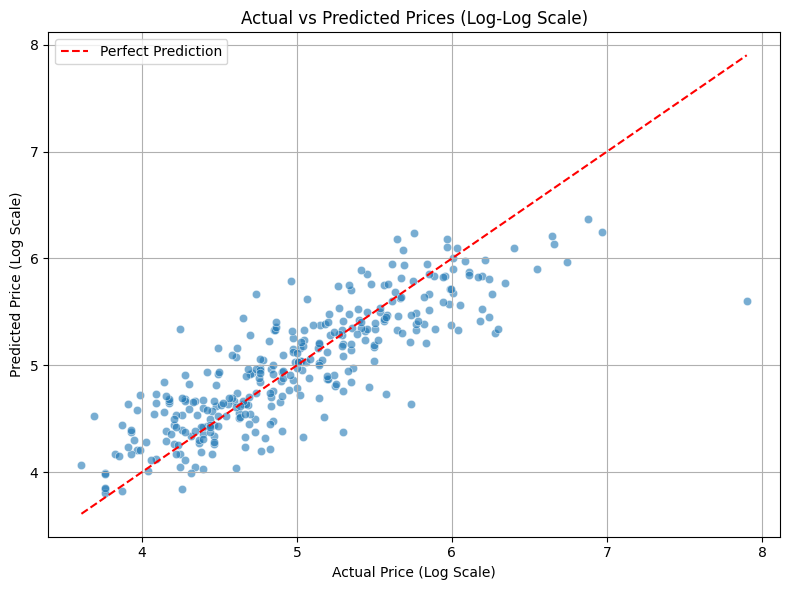

In [21]:
# --- Final Evaluation on Log Scale ---
y_pred_log = rf_model_log.predict(X_test)

# RMSE Calculation (log-scale)
log_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(f"Final Test RMSE (log-scale): {log_rmse:.4f}")

# Scatter plot: Actual vs Predicted (Log Scale)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_log, alpha=0.6)

# Perfect Prediction Line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--r', label='Perfect Prediction')

plt.xlabel("Actual Price (Log Scale)")
plt.ylabel("Predicted Price (Log Scale)")
plt.title("Actual vs Predicted Prices (Log-Log Scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Top 10 Features (Log Scale):
                Feature  Importance
4          accommodates    0.576379
8            avg_rating    0.064321
11   property_type_freq    0.056451
0               host_id    0.054780
9     number_of_reviews    0.049904
3   host_listings_count    0.046200
6              bedrooms    0.045917
10   neighbourhood_freq    0.037698
5             bathrooms    0.023246
1    host_response_rate    0.022221


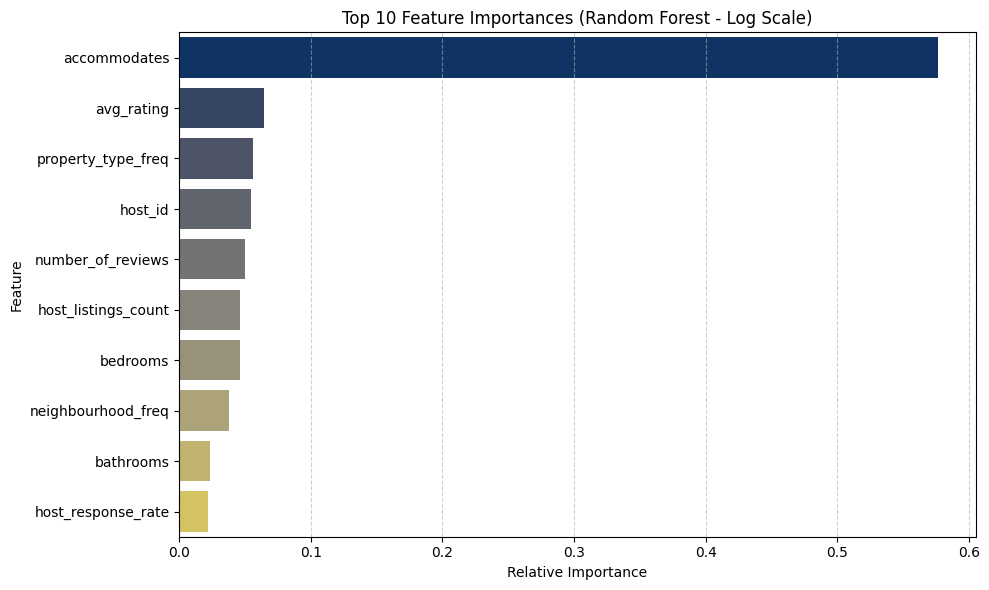

In [22]:
# 1. Fit the model using the correct variable names
rf_model_log.fit(X_train, y_train)

# 2. Extract feature importances from the 'rf' step
rf = rf_model_log.named_steps['rf']
importances = rf.feature_importances_

# 3. Get feature names (with fallback if X_log is not a DataFrame)
feature_names = X_log.columns if hasattr(X_log, 'columns') else [f'Feature {i}' for i in range(len(importances))]

# 4. Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 5. Display top 10 in console
print("Top 10 Features (Log Scale):")
print(importance_df.head(10))

# 6. Plot top 10 features
top_n = 10
plt.figure(figsize=(10, 6))
# Using hue='Feature' to satisfy modern Seaborn requirements
sns.barplot(data=importance_df.head(top_n), x='Importance', y='Feature', hue='Feature', palette='cividis', legend=False)
plt.title('Top 10 Feature Importances (Random Forest - Log Scale)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()




**XGBoost Model**

Train RMSE (log-scale): 0.1897
Test RMSE (log-scale): 0.3707
Train MAE (log-scale): 0.1446, Test MAE (log-scale): 0.2803
R² Score: 0.7173
------------------------------------
Cross-validated RMSE (log-scale): 0.3689
Cross-validated MAE (log-scale): 0.2661
Cross-validated R² Score: 0.7110
------------------------------------


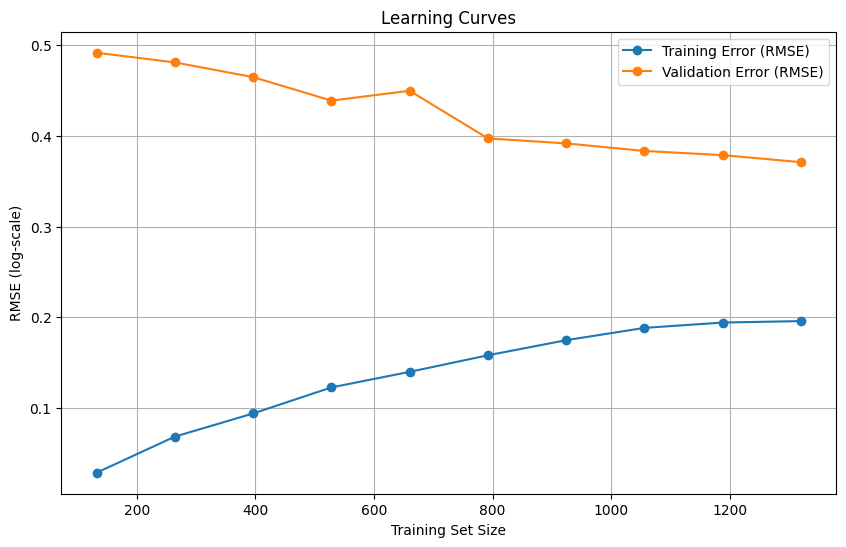

In [23]:
import xgboost as xgb

# 1. Define the Pipeline
xgb_model_log = Pipeline([
    ('xgb', xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ))
])

# 2. Fit and evaluate (Updated variable names)
fit_log_results(xgb_model_log, X_train, X_test, y_train, y_test)

# 3. Cross-validate (Using your kf object)
cross_validate_log_results(xgb_model_log, X_log, y_log, cv=kf)

# 4. Learning curves (Using your kf object)
learn_curves(xgb_model_log, X_log, y_log, cv=kf)


Final Test RMSE (log-scale): 0.3707


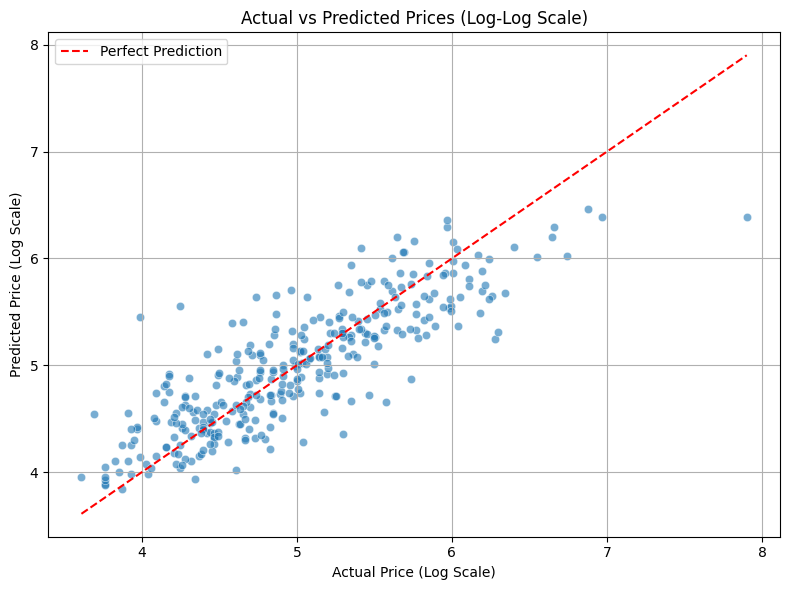

In [24]:
# --- Final Evaluation on Log Scale ---
y_pred_log = xgb_model_log.predict(X_test)

# RMSE Calculation (log-scale)
log_rmse = np.sqrt(mean_squared_error(y_test, y_pred_log))
print(f"Final Test RMSE (log-scale): {log_rmse:.4f}")

# Scatter plot: Actual vs Predicted (Log Scale)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_log, alpha=0.6)

# Perfect Prediction Line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         '--r', label='Perfect Prediction')

plt.xlabel("Actual Price (Log Scale)")
plt.ylabel("Predicted Price (Log Scale)")
plt.title("Actual vs Predicted Prices (Log-Log Scale)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Top 10 Features (XGBoost - Log Scale):
                Feature  Importance
4          accommodates    0.668172
6              bedrooms    0.074514
11   property_type_freq    0.039018
3   host_listings_count    0.033301
7                  beds    0.032646
10   neighbourhood_freq    0.027544
1    host_response_rate    0.027193
5             bathrooms    0.027040
9     number_of_reviews    0.019629
8            avg_rating    0.019389


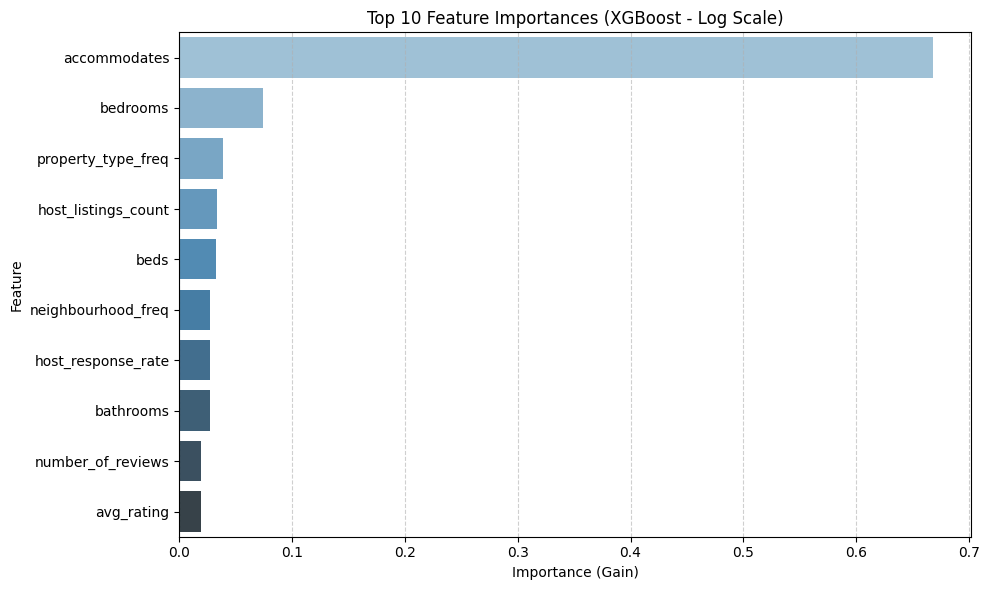

In [25]:
# 1. Fit the model using the correct variable names
xgb_model_log.fit(X_train, y_train)

# 2. Extract feature importances from the 'xgb' step
xgb_reg = xgb_model_log.named_steps['xgb']
importances = xgb_reg.feature_importances_

# 3. Get feature names (with fallback if X_log is not a DataFrame)
feature_names = X_log.columns if hasattr(X_log, 'columns') else [f'Feature {i}' for i in range(len(importances))]

# 4. Create a DataFrame for plotting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 5. Display top 10 in console
print("Top 10 Features (XGBoost - Log Scale):")
print(importance_df.head(10))

# 6. Plot top 10 features
top_n = 10
plt.figure(figsize=(10, 6))
# Using hue='Feature' to satisfy modern Seaborn requirements
sns.barplot(data=importance_df.head(top_n), x='Importance', y='Feature', hue='Feature', palette='Blues_d', legend=False)
plt.title('Top 10 Feature Importances (XGBoost - Log Scale)')
plt.xlabel('Importance (Gain)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


This XGBoost model shows a Very low training error (RMSE 0.0360) and relatively low test error (RMSE 0.1374), indicating strong fit. High R² (0.7173) on test data shows good predictive power. Cross-validation metrics are consistent, confirming model generalizes well. The Learning curves show some gap but decreasing validation error, suggesting manageable complexity without severe overfitting. XGBoost model shows Strong, well-generalizing model with good accuracy and robustness.

Featrue importance from XGBoost model

 Feature importance in XGBoost is measured by gain, indicating the average improvement in model accuracy brought by a feature when used in splits. accommodates is the most impactful feature, contributing the highest gain, showing that the number of guests a listing can host plays a crucial role in price prediction. bedrooms also has a notable impact, followed by neighbourhood_cleansed_freq and property_type_freq, which reflect location and property type relevance. Features like beds, host_listings_count, and host_response_rate provide smaller contributions. avg_rating and number_of_reviews are the least important, suggesting limited influence on pricing. XGBoost’s ability to handle non-linear relationships and interactions makes it a powerful model, and its feature importance results support more targeted feature selection and interpretation of pricing dynamics.



**Save Best Model**

XGBoost saved as the best performing model

In [26]:
# Fit model
xgb_model_log.fit(X_train, y_train)

# Save model to a file
joblib.dump(xgb_model_log, 'xgb_model_log.pkl')

print("Model saved as xgb_model_log.pkl")

Model saved as xgb_model_log.pkl


In [27]:
# Fit model
dt_model_log.fit(X_train, y_train)

# Save model to a file
joblib.dump(dt_model_log, 'dt_model_log.pkl')

print("Model saved as dt_model_log.pkl")

Model saved as dt_model_log.pkl


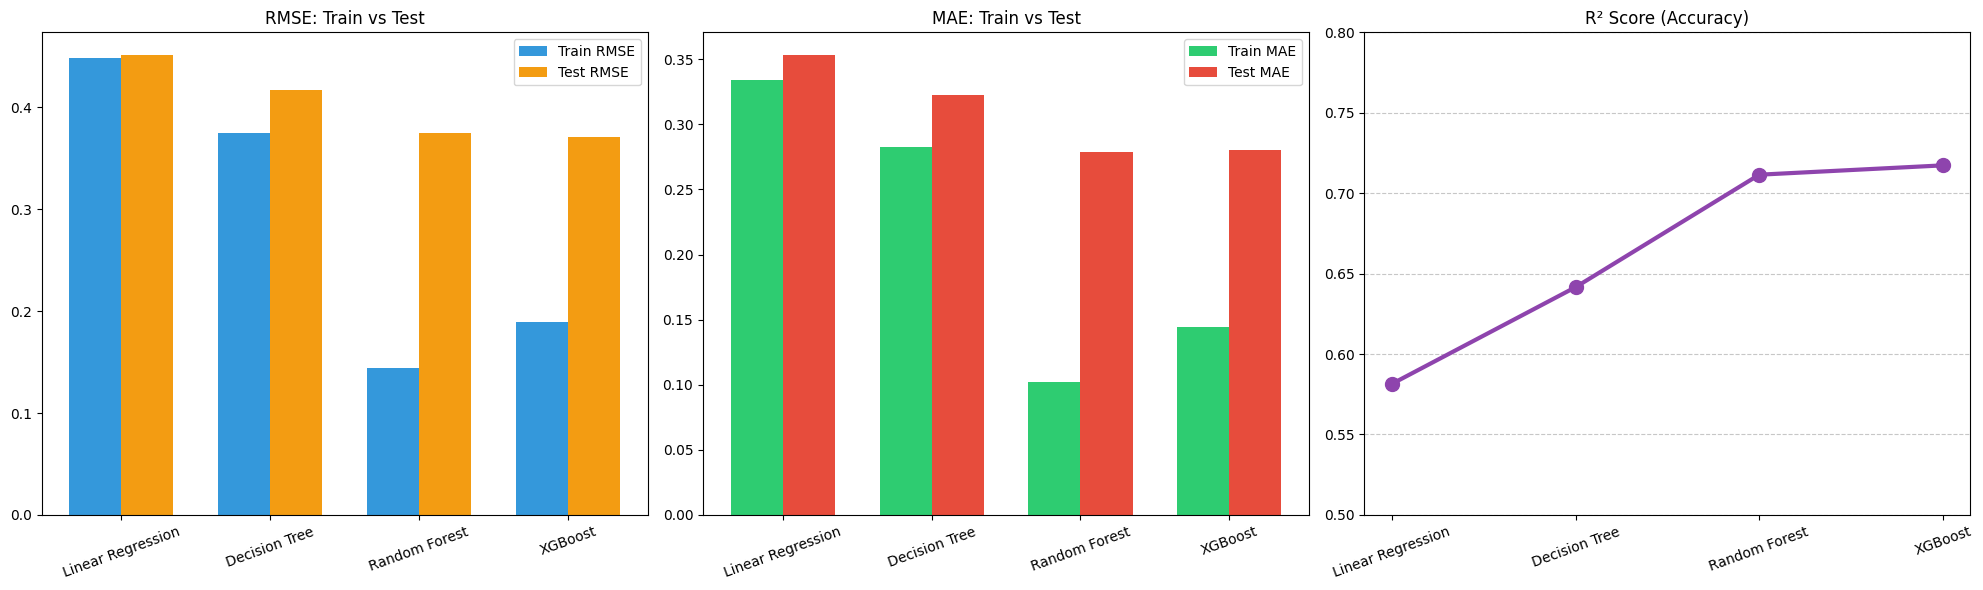

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Data from your results
data = {
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'Train RMSE': [0.4480, 0.3751, 0.1442, 0.1897],
    'Test RMSE': [0.4510, 0.4174, 0.3745, 0.3707],
    'Train MAE': [0.3337, 0.2824, 0.1022, 0.1446],
    'Test MAE': [0.3530, 0.3229, 0.2789, 0.2803],
    'R2 Score': [0.5815, 0.6416, 0.7115, 0.7173]
}
df = pd.DataFrame(data)

# 2. Setup the figure with 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))
x = np.arange(len(df['Model']))
width = 0.35

# Plot 1: RMSE (Lower is Better)
ax1.bar(x - width/2, df['Train RMSE'], width, label='Train RMSE', color='#3498db')
ax1.bar(x + width/2, df['Test RMSE'], width, label='Test RMSE', color='#f39c12')
ax1.set_title('RMSE: Train vs Test')
ax1.set_xticks(x)
ax1.set_xticklabels(df['Model'], rotation=20)
ax1.legend()

# Plot 2: MAE (Lower is Better)
ax2.bar(x - width/2, df['Train MAE'], width, label='Train MAE', color='#2ecc71')
ax2.bar(x + width/2, df['Test MAE'], width, label='Test MAE', color='#e74c3c')
ax2.set_title('MAE: Train vs Test')
ax2.set_xticks(x)
ax2.set_xticklabels(df['Model'], rotation=20)
ax2.legend()

# Plot 3: R2 Score (Higher is Better)
# We use a line plot with points to clearly show the trend of improvement
ax3.plot(df['Model'], df['R2 Score'], marker='o', linestyle='-', color='#8e44ad', linewidth=3, markersize=10)
ax3.set_title('R² Score (Accuracy)')
ax3.set_ylim(0.5, 0.8) # Zooming in on the relevant range
ax3.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()


In [29]:
# load listings
dublin_merged_df = pd.read_csv('dublin_merged_df.csv.gz', compression='gzip')
dublin_merged_df.head()

,id_x,listing_url,name,description,picture_url,host_since,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,...,season_Autumn,distance_to_center,neighbourhood_cleansed_Dn Laoghaire-Rathdown,neighbourhood_cleansed_Dublin City,neighbourhood_cleansed_Fingal,neighbourhood_cleansed_South Dublin,room_type_Entire home/apt,room_type_Hotel room,room_type_Private room,room_type_Shared room
0,44077,https://www.airbnb.com/rooms/44077,cosy comfortable Irish cottage twin,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,2010-08-06,3,100.0,99.0,1,...,0,6.459127,1,0,0,0,0,0,1,0
1,44077,https://www.airbnb.com/rooms/44077,cosy comfortable Irish cottage twin,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,2010-08-06,3,100.0,99.0,1,...,0,6.459127,1,0,0,0,0,0,1,0
2,44077,https://www.airbnb.com/rooms/44077,cosy comfortable Irish cottage twin,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,2010-08-06,3,100.0,99.0,1,...,0,6.459127,1,0,0,0,0,0,1,0
3,44077,https://www.airbnb.com/rooms/44077,cosy comfortable Irish cottage twin,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,2010-08-06,3,100.0,99.0,1,...,0,6.459127,1,0,0,0,0,0,1,0
4,44077,https://www.airbnb.com/rooms/44077,cosy comfortable Irish cottage twin,Our house is a cosy comfortable cottage with ...,https://a0.muscache.com/pictures/525706/050a3a...,2010-08-06,3,100.0,99.0,1,...,0,6.459127,1,0,0,0,0,0,1,0


**Collaborative-Filtering Models**

In [30]:
# Split the data into train and test sets using scikit-learn's train_test_split
train_df, test_df = sklearn_train_test_split(dublin_merged_df[['reviewer_id', 'id_x', 'compound_scores']], test_size=0.2, random_state=42)

# Load train and test datasets with the rating scale (-1, 1)
reader = Reader(rating_scale=(-1, 1))
train_data = Dataset.load_from_df(train_df, reader)
test_data = Dataset.load_from_df(test_df, reader)

So we choose the scale rating of (-1, 1) of the compound_scores which is our sentiment polarity within the rage (-1, 1) This is to ensure accurate interpretation of sentiment values

In [31]:
# Convert train_data to Surprise’s trainset format
#trainset = train_data.build_full_trainset()

**BaselineOnly Model**

In [38]:
from surprise.model_selection import KFold

# 1. Set global seeds
my_seed = 42
random.seed(my_seed)
np.random.seed(my_seed)

# 2. Define a reproducible KFold iterator
kf = KFold(n_splits=5, random_state=my_seed, shuffle=True)

# 3. Use the iterator in cross_validate
baseline_model = BaselineOnly()
cv_baseline = cross_validate(baseline_model, train_data, cv=kf, verbose=True)


Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Estimating biases using als...
Evaluating RMSE, MAE of algorithm BaselineOnly on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.4158  0.4191  0.4184  0.4197  0.4197  0.4185  0.0015  
MAE (testset)     0.3040  0.3062  0.3052  0.3068  0.3065  0.3058  0.0010  
Fit time          2.10    2.11    2.12    2.54    2.49    2.27    0.20    
Test time         0.66    0.22    0.63    0.22    0.87    0.52    0.26    


The baseline model alone gives a simple but stable baseline with an RMSE of 0.41 and MAE of 0.29. The error is low. Which is useful as a benchmark as it is very fast to train and predict

**SlopeOne Model**

In [39]:
# Evualate SlopeOne model
slope_one = SlopeOne()
cv_slopeone = cross_validate(slope_one, train_data, cv=kf, verbose=True)

Evaluating RMSE, MAE of algorithm SlopeOne on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.4265  0.4287  0.4290  0.4309  0.4300  0.4290  0.0015  
MAE (testset)     0.3146  0.3154  0.3152  0.3172  0.3168  0.3158  0.0010  
Fit time          1.79    2.28    1.85    1.87    2.31    2.02    0.23    
Test time         0.40    0.34    0.35    0.80    0.57    0.49    0.17    


With the error a bit higher than the base line model, this shows us that this model performs worse than our BaselineOnly model with a higher RMSE 0.42

**Singular Value Decomposition (SVD) Model**

In [40]:
# Evualate SVD model
svd_model = SVD()
cv_svd_model = cross_validate(svd_model, train_data, cv=kf, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.4162  0.4195  0.4190  0.4201  0.4202  0.4190  0.0015  
MAE (testset)     0.3040  0.3061  0.3055  0.3070  0.3064  0.3058  0.0010  
Fit time          5.49    4.73    5.71    4.53    5.57    5.21    0.48    
Test time         0.72    0.23    0.67    0.22    0.65    0.50    0.22    


**Save BaselineOnly model**

In [41]:
# Initialize the BaselineOnly model
#baseline_model = BaselineOnly()

# Cross-validate the model
#cv_baseline = cross_validate(baseline_model, train_data, cv=5, verbose=True)

# Fit the model on the entire training set
#baseline_model.fit(train_data.build_full_trainset())

# Save the fitted model to a file
joblib.dump(baseline_model, 'baseline_model.pkl')

['baseline_model.pkl']

In [42]:
joblib.dump(cv_svd_model, 'svd_final_model.pkl')

['svd_final_model.pkl']

In [45]:
# Load the model into memory
loaded_model = joblib.load('svd_final_model.pkl')


In [68]:
from surprise import dump

# Save the model ('algo' is your trained model object)
dump.dump('svd_final_model.pkl', algo=loaded_model)

# Model Evaluation

To visualize the latent factors learned by the SVD model, and our data has latent dimensions, we'll use dimensionality reduction techniques like PCA to bring it down to 2D for visualization.

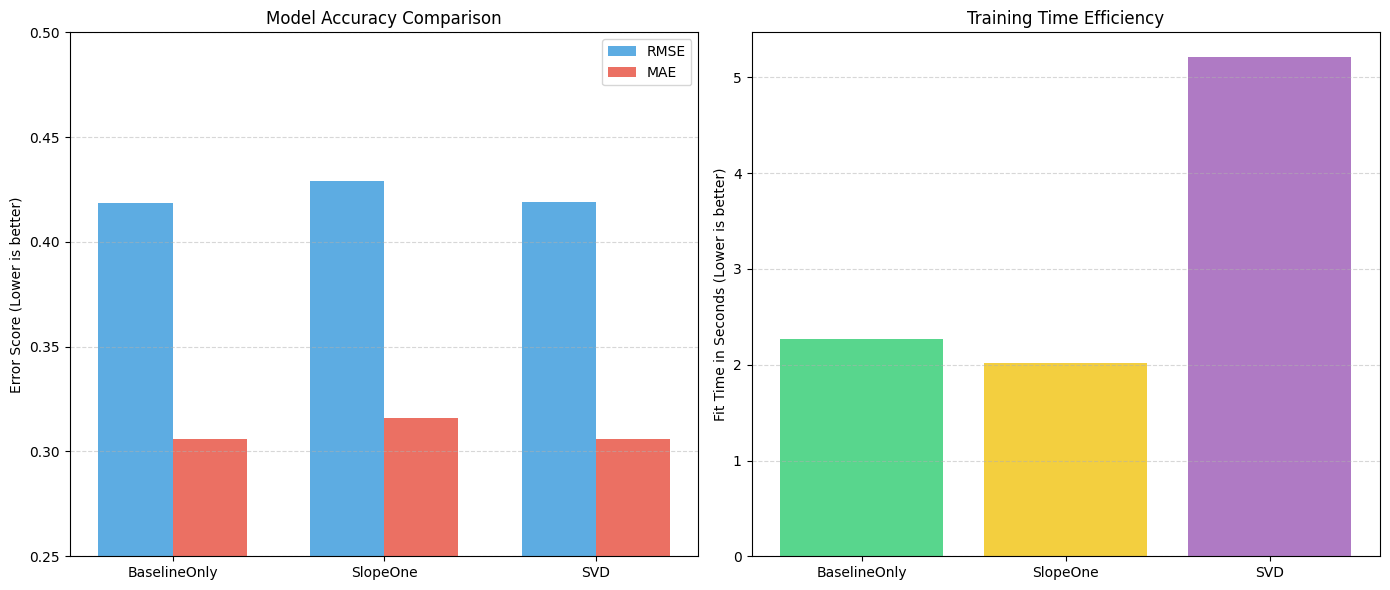

In [52]:
import matplotlib.pyplot as plt
import numpy as np

# Data from your results
models = ['BaselineOnly', 'SlopeOne', 'SVD']
rmse_means = [0.4185, 0.4290, 0.4190]
mae_means = [0.3058, 0.3158, 0.3058]
fit_times = [2.27, 2.02, 5.21]

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Accuracy (RMSE & MAE)
ax1.bar(x - width/2, rmse_means, width, label='RMSE', color='#3498db', alpha=0.8)
ax1.bar(x + width/2, mae_means, width, label='MAE', color='#e74c3c', alpha=0.8)
ax1.set_ylabel('Error Score (Lower is better)')
ax1.set_title('Model Accuracy Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.set_ylim(0.25, 0.5)  # Zoomed in to see small differences
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# Plot 2: Training Efficiency (Fit Time)
ax2.bar(models, fit_times, color=['#2ecc71', '#f1c40f', '#9b59b6'], alpha=0.8)
ax2.set_ylabel('Fit Time in Seconds (Lower is better)')
ax2.set_title('Training Time Efficiency')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


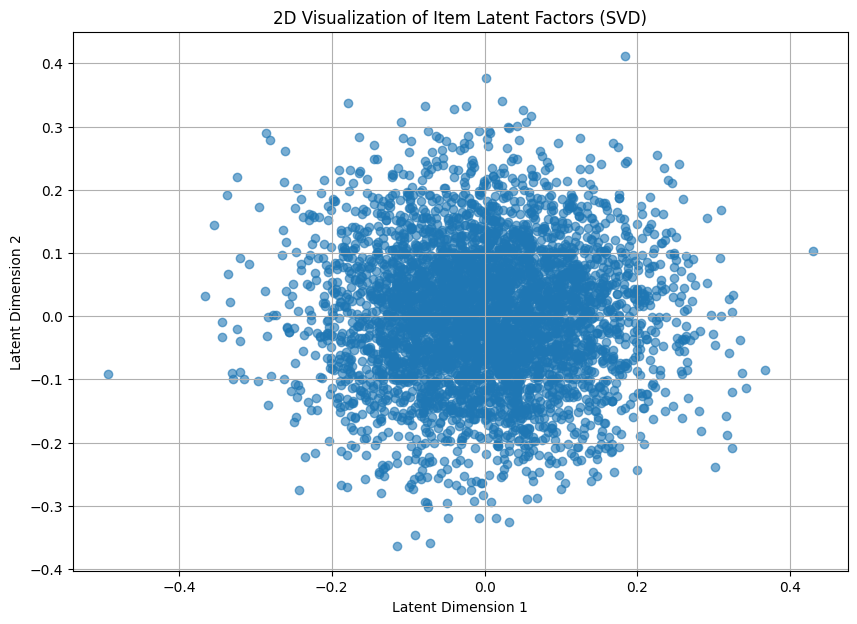

In [51]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Train the final model (Required to create the .qi factors)
final_model = SVD()
trainset = train_data.build_full_trainset()
final_model.fit(trainset)

# 2. Access the trained item factors
item_factors = final_model.qi  # Matrix of shape (n_items, n_factors)

# 3. Reduce to 2D using PCA for visualization
pca = PCA(n_components=2)
item_factors_2d = pca.fit_transform(item_factors)

# 4. Plot the 2D projection
plt.figure(figsize=(10, 7))
plt.scatter(item_factors_2d[:, 0], item_factors_2d[:, 1], alpha=0.6)
plt.title("2D Visualization of Item Latent Factors (SVD)")
plt.xlabel("Latent Dimension 1")
plt.ylabel("Latent Dimension 2")
plt.grid(True)
plt.show()


Most items cluster tightly near the center, indicating that many share similar latent characteristics as learned by the SVD model. There is moderate variance along both latent dimensions, showing that the model has captured meaningful differences between item profiles (e.g., differences in how positively or negatively users respond to them). A few points are scattered far from the center, potentially representing unique or polarizing items (e.g., items with strong sentiment or very distinct user interactions).